<a href="https://colab.research.google.com/github/N1Coder/ml-water-ph-predict/blob/main/water_quality_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Dependencies

In [ ]:
!pip install -q autogluon mljar-supervised pandas numpy matplotlib seaborn scipy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Import Libraries & Konfigurasi Awal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')

# Tahap 10: Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Data & Tahap 1 (EDA)

=== TAHAP 1: Exploratory Data Analysis ===
Jumlah Baris: 26085, Jumlah Kolom: 15

--- Tipe Data ---
split                                                                                                    object
timestep                                                                                                  int64
location_id                                                                                               int64
Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Maximum)    float64
pH, water, unfiltered, field, standard units (Maximum)                                                  float64
pH, water, unfiltered, field, standard units (Minimum)                                                  float64
Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Minimum)    float64
Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Mean)       float64
Diss

,timestep,location_id,"Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Maximum)","pH, water, unfiltered, field, standard units (Maximum)","pH, water, unfiltered, field, standard units (Minimum)","Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Minimum)","Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Mean)","Dissolved oxygen, water, unfiltered, milligrams per liter (Maximum)","Dissolved oxygen, water, unfiltered, milligrams per liter (Mean)","Dissolved oxygen, water, unfiltered, milligrams per liter (Minimum)","Temperature, water, degrees Celsius (Mean)","Temperature, water, degrees Celsius (Minimum)","Temperature, water, degrees Celsius (Maximum)",target
count,26085.000000,2.608500e+04,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000,26085.000000
mean,182.800000,1.138139e+07,0.071648,0.887349,0.030986,0.047079,0.550942,0.857237,0.585189,0.557359,0.588324,0.569588,0.581686,0.663508
std,113.095168,3.552055e+07,0.168408,0.035386,0.122239,0.136686,0.119689,0.031167,0.146308,0.172836,0.200402,0.208671,0.186540,0.029385
min,0.000000,2.198840e+06,0.000526,0.410256,0.000255,0.000508,0.118421,0.719512,0.068182,0.031496,0.059375,0.022436,0.090116,0.574074
25%,88.000000,2.203900e+06,0.001910,0.871795,0.001591,0.001777,0.480263,0.841463,0.507576,0.472441,0.421875,0.400641,0.427326,0.648148
50%,176.000000,2.336152e+06,0.002632,0.884615,0.002220,0.002422,0.546053,0.853659,0.583333,0.566929,0.600000,0.580128,0.595930,0.657407
75%,264.000000,2.337170e+06,0.005497,0.910256,0.003713,0.004902,0.631579,0.878049,0.689394,0.677165,0.753125,0.740385,0.738372,0.675926
max,422.000000,2.198979e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


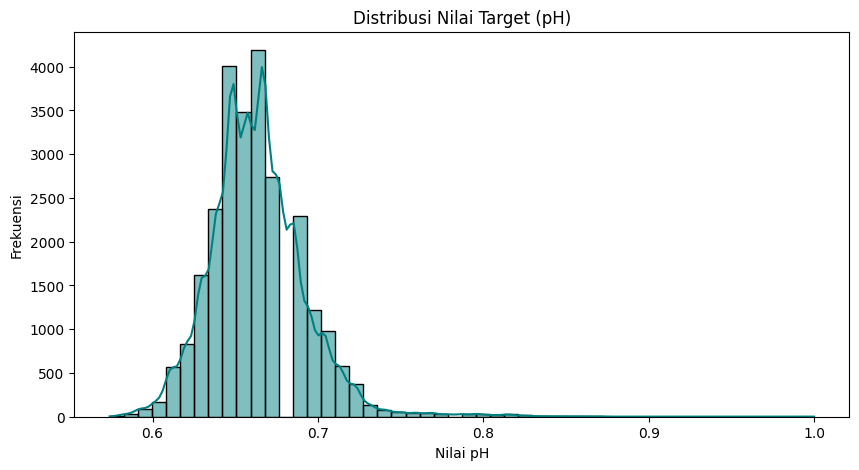

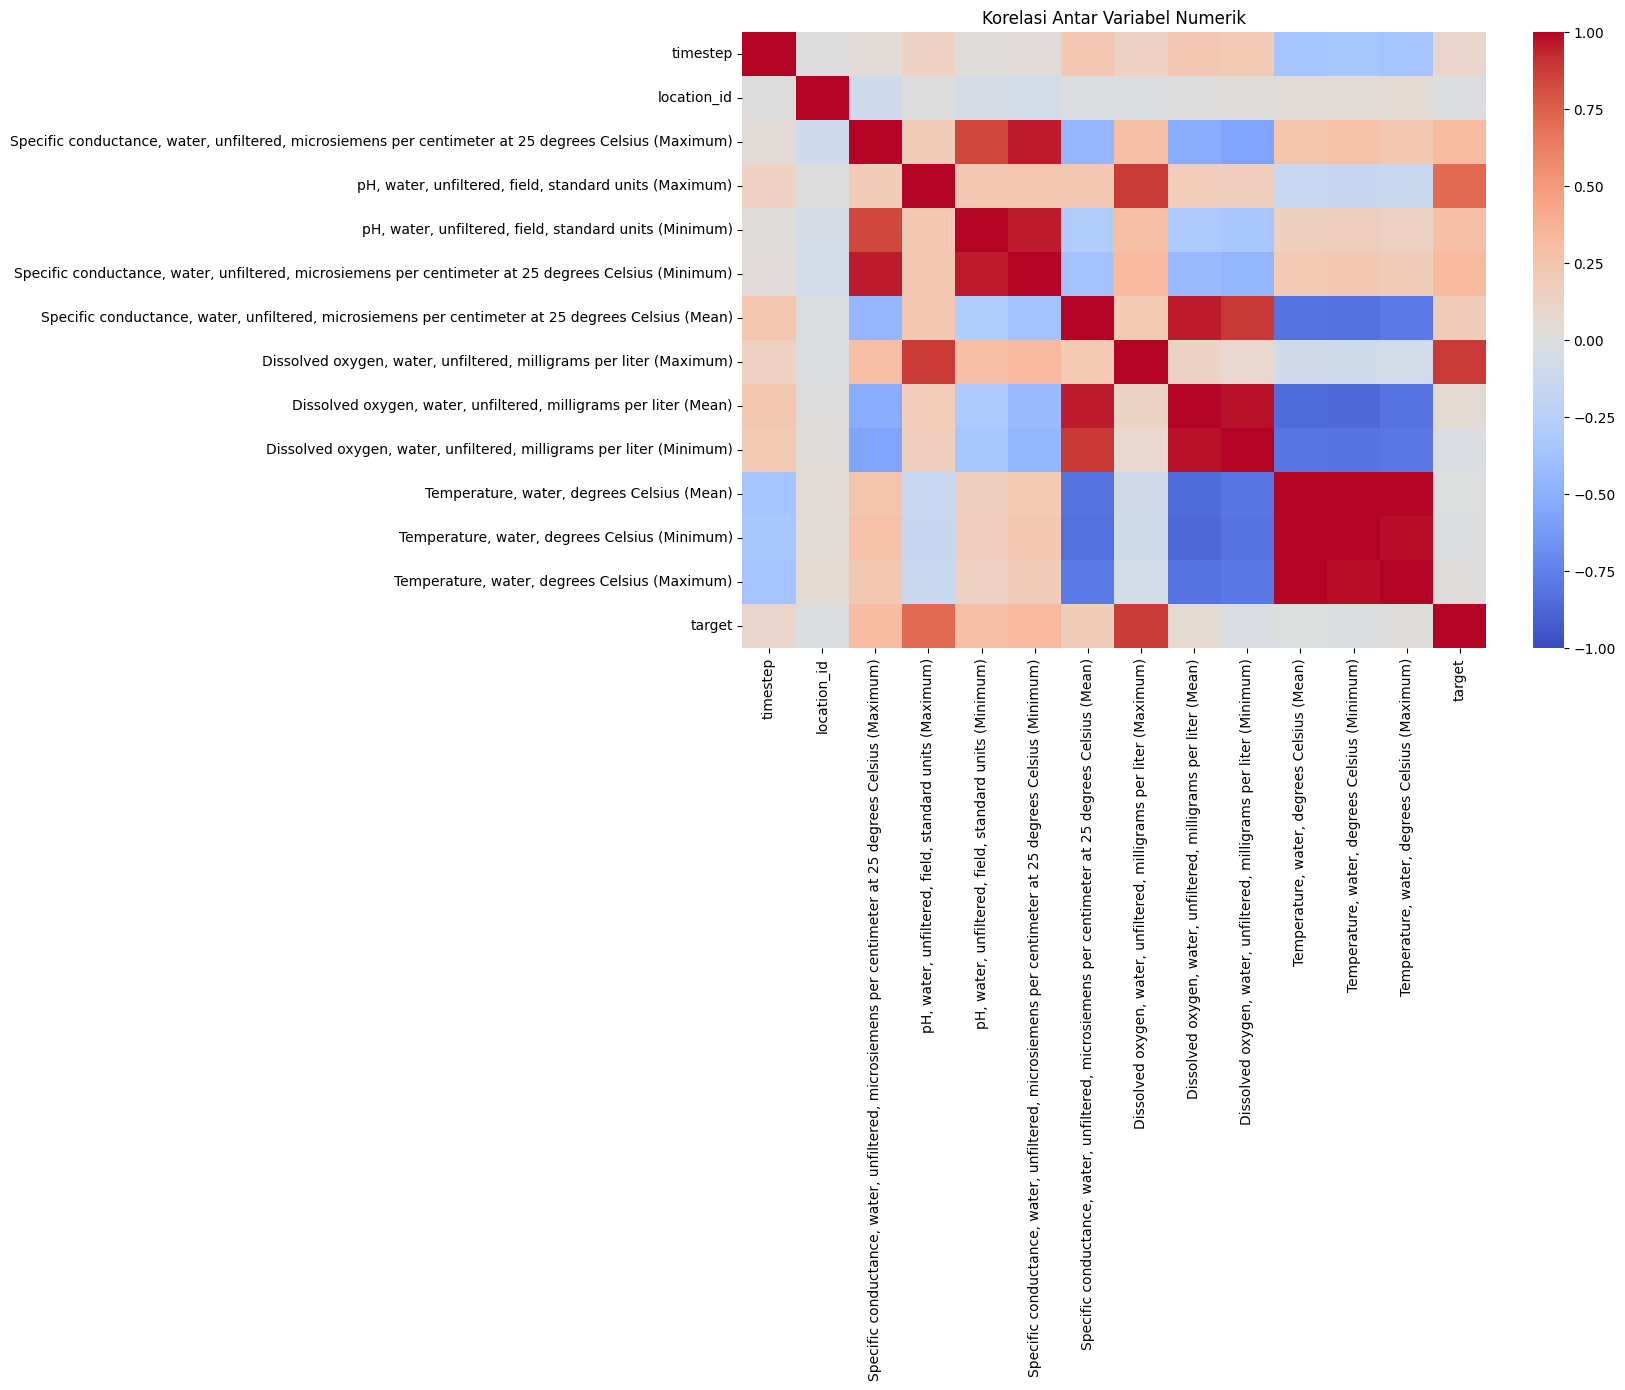

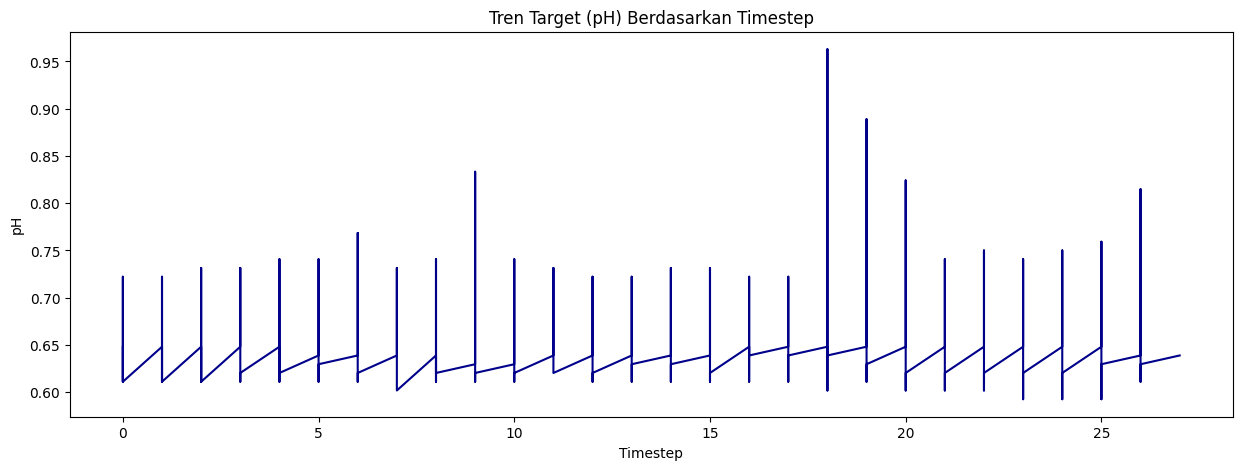

In [ ]:
# Load Dataset
df = pd.read_csv('water_dataset.csv')

# Asumsikan 'target' adalah nilai pH observasi yang akan diforecast
print("=== TAHAP 1: Exploratory Data Analysis ===")
print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")
print("\n--- Tipe Data ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\nJumlah Duplikat: {df.duplicated().sum()}")

print("\n--- Statistik Deskriptif ---")
display(df.describe())

# Visualisasi Distribusi pH (Target)
plt.figure(figsize=(10, 5))
sns.histplot(df['target'], bins=50, kde=True, color='teal')
plt.title('Distribusi Nilai Target (pH)')
plt.xlabel('Nilai pH')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi Korelasi Variabel Numerik
plt.figure(figsize=(12, 8))
num_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

# Visualisasi Tren pH terhadap waktu (Mengambil 1000 data pertama sebagai sampel)
plt.figure(figsize=(15, 5))
plt.plot(df['timestep'][:1000], df['target'][:1000], color='darkblue')
plt.title('Tren Target (pH) Berdasarkan Timestep')
plt.xlabel('Timestep')
plt.ylabel('pH')
plt.show()

# Tahap 2 (Data Preprocessing & Feature Engineering)

In [ ]:
print("=== TAHAP 2: Data Preprocessing ===")

# 1. Identifikasi Kolom Waktu & Konversi
# Karena data menggunakan 'timestep', kita buat synthetic date base untuk ekstraksi time features
base_date = pd.to_datetime('2016-01-28')
df['date'] = base_date + pd.to_timedelta(df['timestep'], unit='d')

# Urutkan berdasarkan lokasi dan waktu
df = df.sort_values(by=['location_id', 'date']).reset_index(drop=True)

# 2. Penanganan Missing Value
df = df.fillna(method='ffill').fillna(method='bfill')

# 3. Feature Engineering: Time-Series
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day
df['DayOfWeek'] = df['date'].dt.dayofweek
df['WeekOfYear'] = df['date'].dt.isocalendar().week.astype(int)

# 4. Feature Engineering: Lags & Rolling Statistics
# Groupby location_id agar perhitungan lag tidak bocor (leak) ke lokasi lain
df['pH_lag_1'] = df.groupby('location_id')['target'].shift(1)
df['pH_lag_3'] = df.groupby('location_id')['target'].shift(3)
df['pH_lag_7'] = df.groupby('location_id')['target'].shift(7)

df['rolling_mean_3'] = df.groupby('location_id')['target'].transform(lambda x: x.rolling(window=3).mean())
df['rolling_mean_7'] = df.groupby('location_id')['target'].transform(lambda x: x.rolling(window=7).mean())
df['rolling_std_3'] = df.groupby('location_id')['target'].transform(lambda x: x.rolling(window=3).std())
df['rolling_std_7'] = df.groupby('location_id')['target'].transform(lambda x: x.rolling(window=7).std())

# Drop NaN hasil pergeseran (Lag)
df_clean = df.dropna().reset_index(drop=True)
print("Preprocessing selesai. Bentuk dataset baru:", df_clean.shape)

=== TAHAP 2: Data Preprocessing ===
Preprocessing selesai. Bentuk dataset baru: (25826, 28)


# Tahap 3 (Time-Series Split)

In [ ]:
print("=== TAHAP 3: Splitting Data ===")
# Split 80:20 (Chronological, No Shuffle)
split_idx = int(len(df_clean) * 0.8)

train_df = df_clean.iloc[:split_idx].copy()
test_df = df_clean.iloc[split_idx:].copy()

print(f"Training Data (80%): {len(train_df)} baris")
print(f"Rentang Waktu Train: {train_df['date'].min().date()} hingga {train_df['date'].max().date()}")

print(f"\nTesting Data (20%): {len(test_df)} baris")
print(f"Rentang Waktu Test: {test_df['date'].min().date()} hingga {test_df['date'].max().date()}")

# Kolom yang tidak digunakan untuk modeling
drop_cols = ['date', 'split', 'timestep']

X_train = train_df.drop(columns=['target'] + drop_cols)
y_train = train_df['target']
X_test = test_df.drop(columns=['target'] + drop_cols)
y_test = test_df['target']

=== TAHAP 3: Splitting Data ===
Training Data (80%): 20660 baris
Rentang Waktu Train: 2023-01-04 hingga 2024-02-27

Testing Data (20%): 5166 baris
Rentang Waktu Test: 2023-01-04 hingga 2024-02-27


# Tahap 4 (Forecasting - AutoGluon Tabular)

In [ ]:
from autogluon.tabular import TabularPredictor

print("=== TAHAP 4: AutoGluon Training ===")
train_ag = train_df.drop(columns=drop_cols)
test_ag = test_df.drop(columns=drop_cols)

# Konfigurasi AutoGluon
predictor_ag = TabularPredictor(
    label='target',
    eval_metric='root_mean_squared_error',
    problem_type='regression'
)

# Training (diberi time_limit agar tidak terlalu lama di Colab, misal 600 detik/10 menit)
predictor_ag.fit(train_data=train_ag, presets='best_quality', time_limit=600)

print("\n--- Leaderboard AutoGluon ---")
display(predictor_ag.leaderboard())

print("\n--- Feature Importance AutoGluon ---")
display(predictor_ag.feature_importance(test_ag))

# Prediksi pada Data Test
pred_ag = predictor_ag.predict(test_ag)

# Forecast 7 Hari ke Depan (Pendekatan Autoregressive Iteratif pada 1 Lokasi Sampel)
sample_loc = df_clean['location_id'].unique()[0]
last_row = df_clean[df_clean['location_id'] == sample_loc].tail(1).copy()
future_ag = []

for step in range(1, 8):
    # Update time attributes
    last_row['date'] = last_row['date'] + pd.Timedelta(days=1)
    last_row['Day'] = last_row['date'].dt.day
    last_row['DayOfWeek'] = last_row['date'].dt.dayofweek

    # Predict step
    step_pred = predictor_ag.predict(last_row.drop(columns=['target'] + drop_cols)).iloc[0]
    future_ag.append({'Date': last_row['date'].iloc[0], 'Forecast_AutoGluon': step_pred})

    # Shift lags for next iteration
    last_row['pH_lag_7'] = last_row['pH_lag_3']
    last_row['pH_lag_3'] = last_row['pH_lag_1']
    last_row['pH_lag_1'] = step_pred

df_forecast_ag = pd.DataFrame(future_ag)
df_forecast_ag.to_csv('forecast_autogluon_7days.csv', index=False)
print("\nHasil forecast AutoGluon 7 hari ke depan telah disimpan ke 'forecast_autogluon_7days.csv'")

No path specified. Models will be saved in: "AutogluonModels/ag-20260612_071820"
Verbosity: 2 (Standard Logging)


=== TAHAP 4: AutoGluon Training ===


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.68 GB / 12.67 GB (84.3%)
Disk Space Avail:   58.27 GB / 112.64 GB (51.7%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disab


--- Leaderboard AutoGluon ---


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,-0.006429,root_mean_squared_error,10.380755,493.021975,0.000952,0.056461,3,True,9
1,LightGBM_BAG_L2,-0.006498,root_mean_squared_error,7.116465,308.255413,1.077213,43.724548,2,True,7
2,WeightedEnsemble_L2,-0.006622,root_mean_squared_error,6.039934,264.557593,0.000682,0.026728,2,True,5
3,LightGBM_BAG_L1,-0.006663,root_mean_squared_error,0.937902,45.954549,0.937902,45.954549,1,True,2
4,LightGBMXT_BAG_L2,-0.006700,root_mean_squared_error,8.275855,315.576750,2.236603,51.045885,2,True,6
5,RandomForestMSE_BAG_L2,-0.006846,root_mean_squared_error,7.065988,398.195081,1.026736,133.664216,2,True,8
6,CatBoost_BAG_L1,-0.006893,root_mean_squared_error,0.130461,91.460056,0.130461,91.460056,1,True,4
7,LightGBMXT_BAG_L1,-0.007099,root_mean_squared_error,4.170091,64.042725,4.170091,64.042725,1,True,1
8,RandomForestMSE_BAG_L1,-0.007190,root_mean_squared_error,0.800798,63.073535,0.800798,63.073535,1,True,3


Computing feature importance via permutation shuffling for 24 features using 5000 rows with 5 shuffle sets...



--- Feature Importance AutoGluon ---


	1875.61s	= Expected runtime (375.12s per shuffle set)
	1606.05s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
rolling_mean_3,0.037861,0.000540,4.966063e-09,5,0.038973,3.674863e-02
"Dissolved oxygen, water, unfiltered, milligrams per liter (Maximum)",0.006896,0.000050,3.270765e-10,5,0.006999,6.793323e-03
pH_lag_1,0.004367,0.000252,1.328043e-06,5,0.004886,3.847386e-03
"Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Mean)",0.000975,0.000042,3.926056e-07,5,0.001061,8.898628e-04
"Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Maximum)",0.000829,0.000088,1.522259e-05,5,0.001010,6.469305e-04
rolling_std_3,0.000800,0.000032,2.960827e-07,5,0.000865,7.344532e-04
pH_lag_3,0.000791,0.000062,4.564649e-06,5,0.000919,6.629870e-04
rolling_mean_7,0.000523,0.000040,4.195031e-06,5,0.000606,4.403209e-04
"Specific conductance, water, unfiltered, microsiemens per centimeter at 25 degrees Celsius (Minimum)",0.000371,0.000032,7.029755e-06,5,0.000437,3.035933e-04
"Temperature, water, degrees Celsius (Maximum)",0.000349,0.000026,3.644047e-06,5,0.000402,2.954960e-04



Hasil forecast AutoGluon 7 hari ke depan telah disimpan ke 'forecast_autogluon_7days.csv'


# Tahap 5 (Forecasting - MLJAR Supervised)

In [ ]:
from supervised.automl import AutoML

print("=== TAHAP 5: MLJAR Supervised Training ===")

# Konfigurasi MLJAR
automl = AutoML(
    mode="Compete",
    eval_metric="rmse",
    algorithms=["Baseline", "Linear", "Random Forest", "Extra Trees", "LightGBM", "Xgboost", "CatBoost", "Neural Network"],
    random_state=RANDOM_STATE,
    total_time_limit=600
)

# Training Model
automl.fit(X_train, y_train)

# Prediksi pada Data Test
pred_mljar = automl.predict(X_test)

# Forecast 7 Hari ke Depan
future_mljar = []
last_row_m = df_clean[df_clean['location_id'] == sample_loc].tail(1).copy()

for step in range(1, 8):
    last_row_m['date'] = last_row_m['date'] + pd.Timedelta(days=1)
    last_row_m['Day'] = last_row_m['date'].dt.day
    last_row_m['DayOfWeek'] = last_row_m['date'].dt.dayofweek

    # Predict step
    X_step = last_row_m.drop(columns=['target'] + drop_cols)
    step_pred_m = automl.predict(X_step)[0]
    future_mljar.append({'Date': last_row_m['date'].iloc[0], 'Forecast_MLJAR': step_pred_m})

    # Shift lags
    last_row_m['pH_lag_7'] = last_row_m['pH_lag_3']
    last_row_m['pH_lag_3'] = last_row_m['pH_lag_1']
    last_row_m['pH_lag_1'] = step_pred_m

df_forecast_mljar = pd.DataFrame(future_mljar)
df_forecast_mljar.to_csv('forecast_mljar_7days.csv', index=False)
print("\nHasil forecast MLJAR 7 hari ke depan telah disimpan ke 'forecast_mljar_7days.csv'")

=== TAHAP 5: MLJAR Supervised Training ===
Linear algorithm was disabled.
AutoML directory: AutoML_1
The task is regression with evaluation metric rmse
AutoML will use algorithms: ['Baseline', 'Random Forest', 'Extra Trees', 'LightGBM', 'Xgboost', 'CatBoost', 'Neural Network']
AutoML is generating and selecting models automatically. Review outputs before important use.
AutoML will stack models
AutoML will ensemble available models
AutoML steps: ['adjust_validation', 'simple_algorithms', 'default_algorithms', 'not_so_random', 'golden_features', 'kmeans_features', 'insert_random_feature', 'features_selection', 'hill_climbing_1', 'hill_climbing_2', 'boost_on_errors', 'ensemble', 'stack', 'ensemble_stacked']
* Step adjust_validation will try to check up to 1 model
1_DecisionTree rmse 0.009007 trained in 0.61 seconds
Adjust validation. Remove: 1_DecisionTree
Validation strategy: 5-fold CV Shuffle
* Step simple_algorithms will try to check up to 1 model
1_Baseline rmse 0.026639 trained in 1.

# Tahap 6 & 8 (Evaluasi Model & Statistical Analysis)

In [ ]:
print("=== TAHAP 6: Evaluasi Model ===")

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mape, r2

metrics_ag = calculate_metrics(y_test, pred_ag)
metrics_mljar = calculate_metrics(y_test, pred_mljar)

df_results = pd.DataFrame({
    'Framework': ['AutoGluon', 'MLJAR'],
    'RMSE': [metrics_ag[0], metrics_mljar[0]],
    'MAE': [metrics_ag[1], metrics_mljar[1]],
    'MAPE': [metrics_ag[2], metrics_mljar[2]],
    'R²': [metrics_ag[3], metrics_mljar[3]]
})
display(df_results)

print("\n=== TAHAP 8: Statistical Analysis ===")
errors_ag = np.abs(y_test - pred_ag)
errors_mljar = np.abs(y_test - pred_mljar)

diff_rmse = metrics_ag[0] - metrics_mljar[0]
diff_mae = metrics_ag[1] - metrics_mljar[1]

print(f"Selisih RMSE (AutoGluon - MLJAR): {diff_rmse:.5f}")
print(f"Selisih MAE (AutoGluon - MLJAR): {diff_mae:.5f}")

# Wilcoxon Signed Rank Test
stat, p_value = wilcoxon(errors_ag, errors_mljar)
print(f"\nWilcoxon Signed-Rank Test:")
print(f"Statistic: {stat:.4f}, p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Kesimpulan: Terdapat perbedaan performa yang signifikan secara statistik (p < 0.05) antara error model AutoGluon dan MLJAR.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan performa yang signifikan secara statistik (p >= 0.05) antara kedua model.")

=== TAHAP 6: Evaluasi Model ===


,Framework,RMSE,MAE,MAPE,R²
0,AutoGluon,0.010125,0.005086,0.007271,0.923989
1,MLJAR,0.172697,0.096478,0.145428,-21.114617



=== TAHAP 8: Statistical Analysis ===
Selisih RMSE (AutoGluon - MLJAR): -0.16257
Selisih MAE (AutoGluon - MLJAR): -0.09139

Wilcoxon Signed-Rank Test:
Statistic: 46443.0000, p-value: 0.0000e+00
Kesimpulan: Terdapat perbedaan performa yang signifikan secara statistik (p < 0.05) antara error model AutoGluon dan MLJAR.


# Tahap 7 (Visualisasi Perbandingan)

=== TAHAP 7: Visualisasi ===


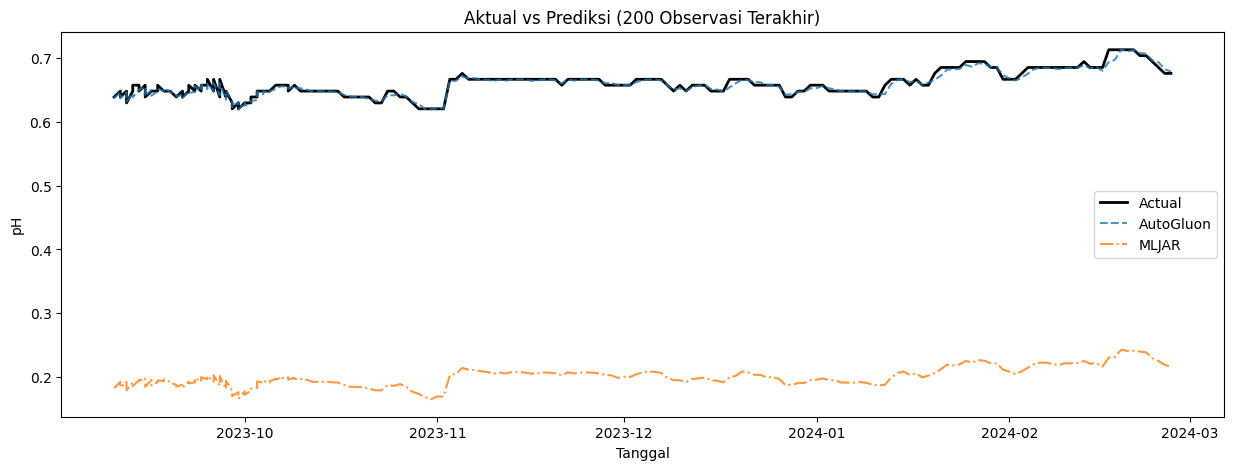

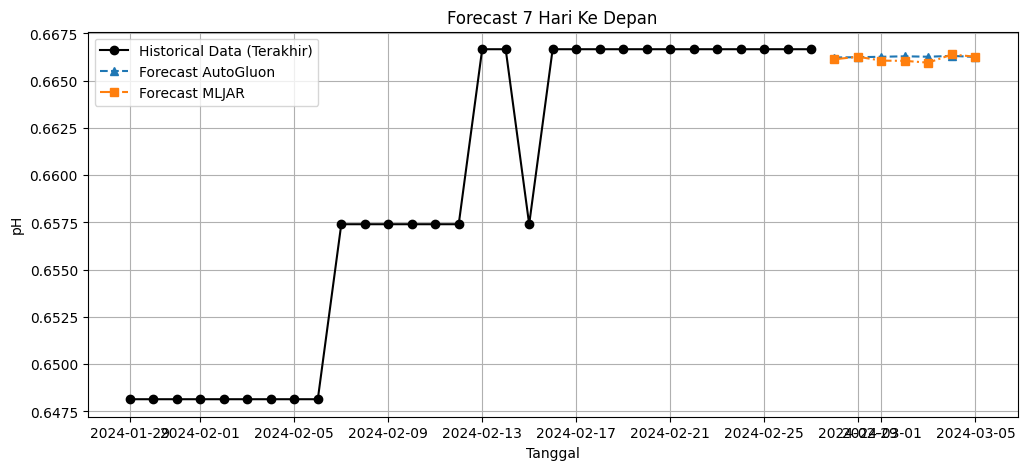

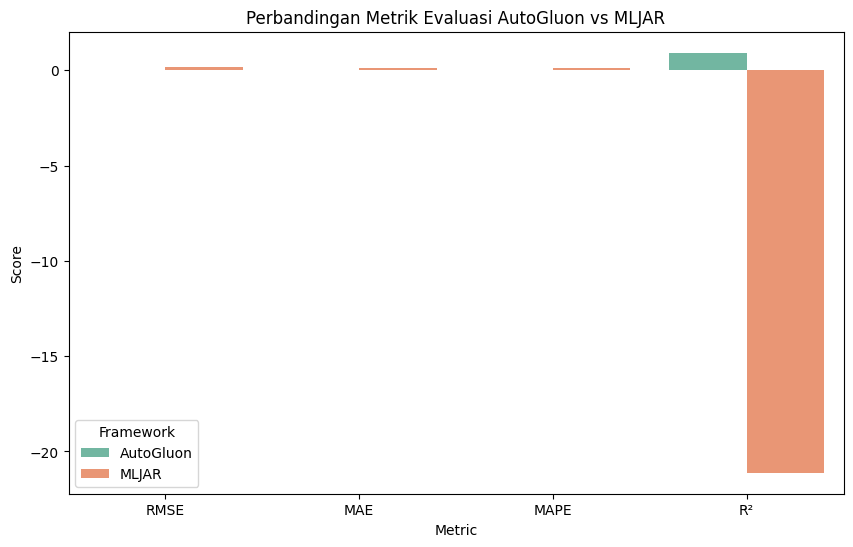

In [ ]:
print("=== TAHAP 7: Visualisasi ===")

# 1. Grafik Aktual vs Prediksi (Plot 200 observasi terakhir agar terlihat polanya)
plt.figure(figsize=(15, 5))
plt.plot(test_df['date'].values[-200:], y_test.values[-200:], label='Actual', color='black', linewidth=2)
plt.plot(test_df['date'].values[-200:], pred_ag.values[-200:], label='AutoGluon', linestyle='--', alpha=0.8)
plt.plot(test_df['date'].values[-200:], pred_mljar[-200:], label='MLJAR', linestyle='-.', alpha=0.8)
plt.title('Aktual vs Prediksi (200 Observasi Terakhir)')
plt.xlabel('Tanggal')
plt.ylabel('pH')
plt.legend()
plt.show()

# 2. Grafik Forecast 7 Hari
df_hist = df_clean[df_clean['location_id'] == sample_loc].tail(30)

plt.figure(figsize=(12, 5))
plt.plot(df_hist['date'], df_hist['target'], label='Historical Data (Terakhir)', color='black', marker='o')
plt.plot(df_forecast_ag['Date'], df_forecast_ag['Forecast_AutoGluon'], label='Forecast AutoGluon', marker='^', linestyle='--')
plt.plot(df_forecast_mljar['Date'], df_forecast_mljar['Forecast_MLJAR'], label='Forecast MLJAR', marker='s', linestyle='-.')
plt.title('Forecast 7 Hari Ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('pH')
plt.legend()
plt.grid(True)
plt.show()

# 3. Bar Chart Perbandingan Metrik
df_melt = df_results.melt(id_vars="Framework", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Framework', palette='Set2')
plt.title('Perbandingan Metrik Evaluasi AutoGluon vs MLJAR')
plt.show()